## Урок 10. Домашнее задание

### 10.1 Домашнее задание начального уровня

Обучите *k-means* для количества кластеров $k=4$ на датасете `data/clustering.pkl`. Как изменилась метрика силуэтта? Стало лучше или хуже? Какое количество кластеров лучше, два или четыре?

In [1]:
# -- ВАШ КОД ТУТ --
# -- ВАШ КОД ТУТ --
import pickle
import numpy as np

# данные получены с помощью функции make_classification
with open('data/clustering.pkl', 'rb') as f:
    data_clustering = pickle.load(f)

X = np.array(data_clustering['X'])
Y = np.array(data_clustering['Y'])
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4).fit(X)

from sklearn.metrics import silhouette_score

score = silhouette_score(X, model.labels_)

print("Качество кластеризации по метрике силуэтта %.3f" % score)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3504\972602178.py:8: DeprecationWarning: numpy.core._multiarray_umath is deprecated and has been renamed to numpy._core._multiarray_umath. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core._multiarray_umath._reconstruct.
  data_clustering = pickle.load(f)


Качество кластеризации по метрике силуэтта 0.443



### 10.2 Домашнее задание начального уровня

Обучите *k-means* для количества кластеров $k=4$ на датасете `data/clustering.pkl`. Как изменилась метрика *AMI*? Стало лучше или хуже? Какое количество кластеров лучше по метрике AMI?

In [2]:
# -- ВАШ КОД ТУТ --
from sklearn.metrics.cluster import adjusted_mutual_info_score
score = adjusted_mutual_info_score(Y, model.labels_, average_method='arithmetic')

print("Качество кластеризации по метрике AMI %.3f" % score)

Качество кластеризации по метрике AMI 0.584



### 10.3 Домашнее задание высокого уровня

Загрузите датасет `clustering_hw.csv` из приложенной директории `data` и визуализируйте данные. Должно получится как-то так:

![clustering_hw](https://248006.selcdn.ru/public/DS.%20Block%202.%20M7/clustering_hw.png)

В рамках домашней работы

1. вычислите оптимальное количество кластеров $k$
1. обучите k-means с количеством кластеров  $k$
1. к какому кластеру принадлежит точка $x=(5, 8)$? к какому кластеру принадлежит точка $x=(0, 5)$? Они принадлежат к разным кластерам или одному?
1. Каково качество кластеризации по AMI

         x1        x2  y
0  6.221343  4.968753  2
1  7.360892  8.857455  2
2 -0.108178  4.730723  1
3  3.127358  1.927986  0
4 -0.817259  6.759974  1


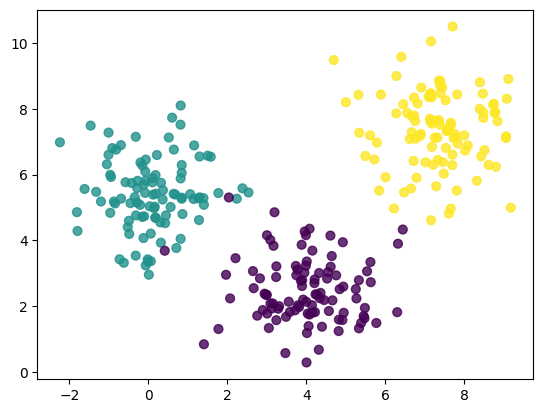

In [5]:
# -- ВАШ КОД ТУТ --
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('data/7.10_clustering_hw.csv')
print(df.head())

plt.scatter(df['x1'], df['x2'], s=40, c=df['y'], marker='o', alpha=0.8, label='data')
plt.show()

### Заключение

Мы познакомились с двумя метриками

* Silhouette. Её используем, когда есть только сами объекты, а метки кластеров отсутствуют в обучающей выборке
* AMI. Её используем, когда известны "истинные" метки кластеров

Метрик намного больше - о них можно почитать [ в документации sklearn](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics)

cluster_num 1, metric 1105.8973781101085
cluster_num 2, metric 663.5712032768091
cluster_num 3, metric 374.6589714184052
cluster_num 4, metric 349.5793730721086
cluster_num 5, metric 327.25148614114744
cluster_num 6, metric 301.5878775343317
cluster_num 7, metric 283.9486018009391
best cluster num: 3
[np.float64(0.5381432366375615), np.float64(0.6531655784722371), np.float64(0.08680698004710354), np.float64(0.8902808818012108), np.float64(1.1493971053404557), np.float64(0.6873264007271356)]


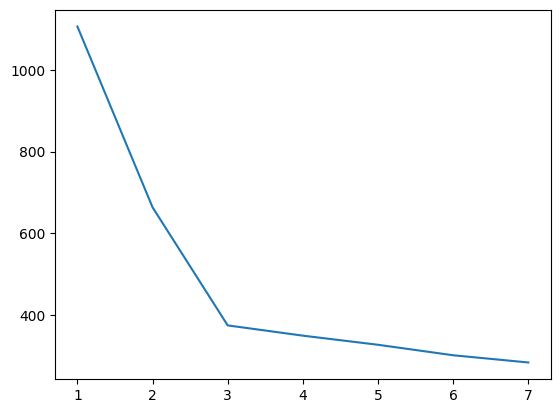

In [6]:
metrics = []
MAX_CLUSTERS = 8
from sklearn.metrics.pairwise import euclidean_distances

X = df[['x1','x2']]
for cluster_num in range(1, MAX_CLUSTERS):
    kmeans_model = KMeans(n_clusters=cluster_num, random_state=99).fit(X)
    centroids, labels = kmeans_model.cluster_centers_, kmeans_model.labels_
    metric = 0
    for centroid_label in range(cluster_num):
        metric += euclidean_distances(
            X[labels==centroid_label],
            centroids[centroid_label,:].reshape(1,-1)
        ).sum(axis=0)[0]
    print("cluster_num %s, metric %s" % (cluster_num, metric))
    metrics.append(metric)
    
D = []
for i in range(0, len(metrics)-1):
    d = abs(metrics[i+1]-metrics[i])/abs(metrics[i]-metrics[i-1])
    D.append(d)
print("best cluster num: %s" % (np.argmin(D)+1))
print(D)

plt.plot([i+1 for i in range(len(metrics))], metrics)
plt.show()

In [8]:
model = KMeans(n_clusters=3).fit(X)
new_point1 = np.array([[5.0, 8.0]])  # X и Y координаты новой точки
new_point2 = np.array([[0.0, 5.0]])  # X и Y координаты новой точки
cluster_index1 = model.predict(new_point1)
cluster_index2 = model.predict(new_point2)
print(f"Точка 1 принадлежит кластеру: {cluster_index1[0]}")
print(f"Точка 2 принадлежит кластеру: {cluster_index2[0]}")

Точка 1 принадлежит кластеру: 0
Точка 2 принадлежит кластеру: 1


C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [9]:
from sklearn.metrics.cluster import adjusted_mutual_info_score

score = adjusted_mutual_info_score(df['y'], model.labels_, average_method='arithmetic')
print("Качество кластеризации по метрике AMI %.3f" % score)

Качество кластеризации по метрике AMI 0.970
